# Otimização de Políticas de Intervenção em MOOCs

## Problema

**Maximizar** o ganho esperado de retenção:

$$\max \sum_{i} \sum_{t} \sum_{r} \text{gain}[i,t,r] \cdot x[i,r,t]$$

**Sujeito a:**
- $\sum_{i} \sum_{r} \text{custo}[r] \cdot x[i,r,t] \leq B \quad \forall t$ (orçamento semanal)
- $\sum_{t} \sum_{r} x[i,r,t] \leq M \quad \forall i$ (limite por aluno)
- $\sum_{r} x[i,r,t] \leq 1 \quad \forall i, t$ (uma intervenção por semana)
- $x[i,r,t] \in \{0, 1\}$

## Métodos
1. **Exato — PuLP/CBC** (Branch-and-Bound)
2. **Guloso** (baseline)
3. **Simulated Annealing**
4. **GRASP**

In [16]:
%pip install pulp --quiet

import pandas as pd
import numpy as np
import pickle
import time
import random
import math
import warnings
warnings.filterwarnings('ignore')

# Carregar dados de ganho
gains_df = pd.read_csv('data/gains.csv')

print(f"Registros de ganho: {len(gains_df):,}")
print(f"Usuários: {gains_df['username'].nunique()}")
print(f"Semanas: {sorted(gains_df['semana'].unique())}")
print(f"Intervenções: {gains_df['tipo_interv'].unique()}")

INTERVENCOES = {
    'R1_email': {'custo': 1, 'efetividade': 0.15},
    'R2_tutor': {'custo': 5, 'efetividade': 0.45},
    'R3_recuperacao': {'custo': 2, 'efetividade': 0.25},
}

Note: you may need to restart the kernel to use updated packages.
Registros de ganho: 9,000
Usuários: 300
Semanas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Intervenções: ['R1_email' 'R2_tutor' 'R3_recuperacao']


In [17]:
# ============================================================
# Parâmetros do problema
# ============================================================
BUDGET_POR_SEMANA = 20   # B: orçamento máximo de custo por semana
MAX_INTERV_ALUNO  = 3    # M: máximo de intervenções por aluno ao longo do curso
N_SEMANAS = 10
TIPOS = list(INTERVENCOES.keys())

# Indexação dos usuários
todos_usuarios = sorted(gains_df['username'].unique())
N_USUARIOS_TOTAL = len(todos_usuarios)

print(f"Parâmetros: B={BUDGET_POR_SEMANA}, M={MAX_INTERV_ALUNO}, T={N_SEMANAS}")
print(f"Usuários totais: {N_USUARIOS_TOTAL}")
print(f"Tamanho do espaço de decisão (300 alunos): {N_USUARIOS_TOTAL * len(TIPOS) * N_SEMANAS:,}")

Parâmetros: B=20, M=3, T=10
Usuários totais: 300
Tamanho do espaço de decisão (300 alunos): 9,000


In [18]:
# ============================================================
# Estrutura de dados central: gain_matrix[usuario][semana][tipo]
# ============================================================
def build_gain_matrix(usuarios):
    """Retorna gain[u][t][r] e custo[r] para a lista de usuários fornecida."""
    sub = gains_df[gains_df['username'].isin(usuarios)]
    gain = {}
    for u in usuarios:
        gain[u] = {}
        for t in range(N_SEMANAS):
            gain[u][t] = {}
            for r in TIPOS:
                row = sub[(sub['username']==u) & (sub['semana']==t) & (sub['tipo_interv']==r)]
                gain[u][t][r] = float(row['gain'].values[0]) if len(row) > 0 else 0.0
    custo = {r: INTERVENCOES[r]['custo'] for r in TIPOS}
    return gain, custo

def calcular_ganho_total(solucao, gain):
    """solucao: dict {(u,t,r): 1/0}"""
    return sum(gain[u][t][r] for (u,t,r),v in solucao.items() if v == 1)

def verificar_viabilidade(solucao, usuarios, custo):
    """Retorna True se a solução satisfaz todas as restrições."""
    for t in range(N_SEMANAS):
        custo_semana = sum(custo[r] for (u,ts,r),v in solucao.items() if ts==t and v==1)
        if custo_semana > BUDGET_POR_SEMANA:
            return False, f"Orçamento violado semana {t}"
    for u in usuarios:
        total = sum(1 for (us,t,r),v in solucao.items() if us==u and v==1)
        if total > MAX_INTERV_ALUNO:
            return False, f"Limite aluno violado: {u}"
        for t in range(N_SEMANAS):
            na_semana = sum(1 for (us,ts,r),v in solucao.items() if us==u and ts==t and v==1)
            if na_semana > 1:
                return False, f"Mais de 1 interv/semana: {u}, t={t}"
    return True, "OK"

print("Funções auxiliares definidas.")

Funções auxiliares definidas.


---
## Método 1: Exato — PuLP + CBC (Branch-and-Bound)

Aplicado sobre **subconjunto de 50 alunos** para garantir tempo de execução razoável.

In [19]:
import pulp

# Subset de 50 alunos para o método exato
np.random.seed(42)
usuarios_exato = sorted(np.random.choice(todos_usuarios, size=50, replace=False).tolist())
gain_ex, custo_ex = build_gain_matrix(usuarios_exato)

print(f"Instância exata: {len(usuarios_exato)} alunos")
print(f"Variáveis binárias: {len(usuarios_exato) * N_SEMANAS * len(TIPOS)}")

Instância exata: 50 alunos
Variáveis binárias: 1500


In [20]:
t0 = time.time()

prob = pulp.LpProblem("mooc_interv_exato", pulp.LpMaximize)

# Variáveis de decisão
x = pulp.LpVariable.dicts(
    "x",
    [(u, t, r) for u in usuarios_exato for t in range(N_SEMANAS) for r in TIPOS],
    cat='Binary'
)

# Função objetivo
prob += pulp.lpSum(
    gain_ex[u][t][r] * x[(u, t, r)]
    for u in usuarios_exato
    for t in range(N_SEMANAS)
    for r in TIPOS
)

# Restrição 1: orçamento semanal
for t in range(N_SEMANAS):
    prob += (
        pulp.lpSum(custo_ex[r] * x[(u, t, r)] for u in usuarios_exato for r in TIPOS)
        <= BUDGET_POR_SEMANA,
        f"budget_t{t}"
    )

# Restrição 2: máximo de intervenções por aluno
for u in usuarios_exato:
    prob += (
        pulp.lpSum(x[(u, t, r)] for t in range(N_SEMANAS) for r in TIPOS)
        <= MAX_INTERV_ALUNO,
        f"max_interv_{u[:8]}"
    )

# Restrição 3: uma intervenção por aluno por semana
for u in usuarios_exato:
    for t in range(N_SEMANAS):
        prob += (
            pulp.lpSum(x[(u, t, r)] for r in TIPOS) <= 1,
            f"uma_interv_{u[:8]}_t{t}"
        )

# Resolver com time limit de 120s
solver = pulp.PULP_CBC_CMD(msg=1, timeLimit=120)
prob.solve(solver)

t_exato = time.time() - t0
ganho_exato = pulp.value(prob.objective)

print(f"\nStatus: {pulp.LpStatus[prob.status]}")
print(f"Ganho ótimo (50 alunos): {ganho_exato:.4f}")
print(f"Tempo: {t_exato:.2f}s")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/administrador/.local/lib/python3.10/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/ad8600a7e8f244c087ac53d156848175-pulp.mps -max -sec 120 -timeMode elapsed -branch -printingOptions all -solution /tmp/ad8600a7e8f244c087ac53d156848175-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 565 COLUMNS
At line 9566 RHS
At line 10127 BOUNDS
At line 11628 ENDATA
Problem MODEL has 560 rows, 1500 columns and 4500 elements
Coin0008I MODEL read with 0 errors
seconds was changed from 1e+100 to 120
Option for timeMode changed from cpu to elapsed
Continuous objective value is 25.2666 - 0.01 seconds
Cgl0004I processed model has 560 rows, 1500 columns (1500 integer (1500 of which binary)) and 4500 elements
Cbc0038I Initial state - 6 integers unsatisfied sum - 3
Cbc0038I Pass   1: suminf.    1.00000 (2) obj. -25.022 iterations 113
Cbc0038I Pass   2: suminf.    0.500

In [21]:
# Extrair solução exata
solucao_exata = {}
for u in usuarios_exato:
    for t in range(N_SEMANAS):
        for r in TIPOS:
            solucao_exata[(u, t, r)] = int(round(x[(u, t, r)].varValue or 0))

interv_realizadas_exato = sum(v for v in solucao_exata.values())
print(f"Total de intervenções: {interv_realizadas_exato}")
print(f"Distribuição por tipo:")
for r in TIPOS:
    n = sum(1 for (u,t,rt),v in solucao_exata.items() if rt==r and v==1)
    print(f"  {r}: {n}")

Total de intervenções: 137
Distribuição por tipo:
  R1_email: 74
  R2_tutor: 0
  R3_recuperacao: 63


---
## Método 2: Guloso (Baseline)

Ordenar todas as triplas `(i, t, r)` por `gain/custo` decrescente e selecionar gulozamente respeitando as restrições.

In [22]:
def guloso(usuarios, gain, custo):
    candidatos = []
    for u in usuarios:
        for t in range(N_SEMANAS):
            for r in TIPOS:
                g = gain[u][t][r]
                c = custo[r]
                candidatos.append((g / c if c > 0 else 0, g, c, u, t, r))

    candidatos.sort(reverse=True)

    solucao = {(u,t,r): 0 for u in usuarios for t in range(N_SEMANAS) for r in TIPOS}
    budget_usado = [0] * N_SEMANAS
    interv_aluno = {u: 0 for u in usuarios}
    interv_semana_aluno = {(u,t): 0 for u in usuarios for t in range(N_SEMANAS)}

    for ratio, g, c, u, t, r in candidatos:
        if (
            budget_usado[t] + c <= BUDGET_POR_SEMANA
            and interv_aluno[u] < MAX_INTERV_ALUNO
            and interv_semana_aluno[(u,t)] == 0
        ):
            solucao[(u,t,r)] = 1
            budget_usado[t] += c
            interv_aluno[u] += 1
            interv_semana_aluno[(u,t)] += 1

    ganho = sum(gain[u][t][r] for (u,t,r),v in solucao.items() if v==1)
    return solucao, ganho

# Aplicar sobre os 50 alunos do método exato (para comparação com gap)
t0 = time.time()
sol_guloso_50, ganho_guloso_50 = guloso(usuarios_exato, gain_ex, custo_ex)
t_guloso_50 = time.time() - t0
print(f"[50 alunos] Ganho Guloso: {ganho_guloso_50:.4f}  |  Tempo: {t_guloso_50*1000:.1f}ms")

# Aplicar sobre os 300 alunos
gain_300, custo_300 = build_gain_matrix(todos_usuarios)
t0 = time.time()
sol_guloso_300, ganho_guloso_300 = guloso(todos_usuarios, gain_300, custo_300)
t_guloso_300 = time.time() - t0
print(f"[300 alunos] Ganho Guloso: {ganho_guloso_300:.4f}  |  Tempo: {t_guloso_300*1000:.1f}ms")

[50 alunos] Ganho Guloso: 20.0494  |  Tempo: 4.1ms
[300 alunos] Ganho Guloso: 29.4228  |  Tempo: 18.1ms


---
## Método 3: Simulated Annealing

In [23]:
def simulated_annealing(
    usuarios, gain, custo,
    T0=1.0, alpha=0.995, T_min=1e-4, max_iter=10000, seed=42
):
    rng = random.Random(seed)
    
    # Solução inicial gulosa
    solucao, _ = guloso(usuarios, gain, custo)
    
    budget_usado = [0] * N_SEMANAS
    interv_aluno = {u: 0 for u in usuarios}
    interv_semana_aluno = {(u,t): 0 for u in usuarios for t in range(N_SEMANAS)}
    for (u,t,r),v in solucao.items():
        if v == 1:
            budget_usado[t] += custo[r]
            interv_aluno[u] += 1
            interv_semana_aluno[(u,t)] += 1

    current_gain = sum(gain[u][t][r] for (u,t,r),v in solucao.items() if v==1)
    best_gain = current_gain
    best_sol = dict(solucao)
    
    historico = [current_gain]
    T = T0

    for it in range(max_iter):
        move = rng.choice(['insert', 'remove', 'swap'])

        if move == 'insert':
            u = rng.choice(usuarios)
            t = rng.randint(0, N_SEMANAS - 1)
            r = rng.choice(TIPOS)
            if (
                solucao.get((u,t,r), 0) == 0
                and interv_semana_aluno.get((u,t),0) == 0
                and interv_aluno.get(u,0) < MAX_INTERV_ALUNO
                and budget_usado[t] + custo[r] <= BUDGET_POR_SEMANA
            ):
                delta = gain[u][t][r]
                if delta > 0 or rng.random() < math.exp(delta / T):
                    solucao[(u,t,r)] = 1
                    budget_usado[t] += custo[r]
                    interv_aluno[u] += 1
                    interv_semana_aluno[(u,t)] += 1
                    current_gain += delta

        elif move == 'remove':
            ativos = [(u,t,r) for (u,t,r),v in solucao.items() if v==1]
            if ativos:
                u, t, r = rng.choice(ativos)
                delta = -gain[u][t][r]
                if delta > 0 or rng.random() < math.exp(delta / T):
                    solucao[(u,t,r)] = 0
                    budget_usado[t] -= custo[r]
                    interv_aluno[u] -= 1
                    interv_semana_aluno[(u,t)] -= 1
                    current_gain += delta

        elif move == 'swap':
            ativos = [(u,t,r) for (u,t,r),v in solucao.items() if v==1]
            if ativos:
                u1, t1, r1 = rng.choice(ativos)
                r2 = rng.choice([r for r in TIPOS if r != r1])
                diff_custo = custo[r2] - custo[r1]
                if budget_usado[t1] + diff_custo <= BUDGET_POR_SEMANA:
                    delta = gain[u1][t1][r2] - gain[u1][t1][r1]
                    if delta > 0 or rng.random() < math.exp(delta / T):
                        solucao[(u1,t1,r1)] = 0
                        solucao[(u1,t1,r2)] = 1
                        budget_usado[t1] += diff_custo
                        current_gain += delta

        if current_gain > best_gain:
            best_gain = current_gain
            best_sol = dict(solucao)

        if it % 200 == 0:
            historico.append(current_gain)

        T = max(T * alpha, T_min)

    return best_sol, best_gain, historico

print("Simulated Annealing definido.")

Simulated Annealing definido.


[50 alunos] SA: ganho=21.1091  |  Tempo: 0.72s
[300 alunos] SA: ganho=29.4228  |  Tempo: 4.21s


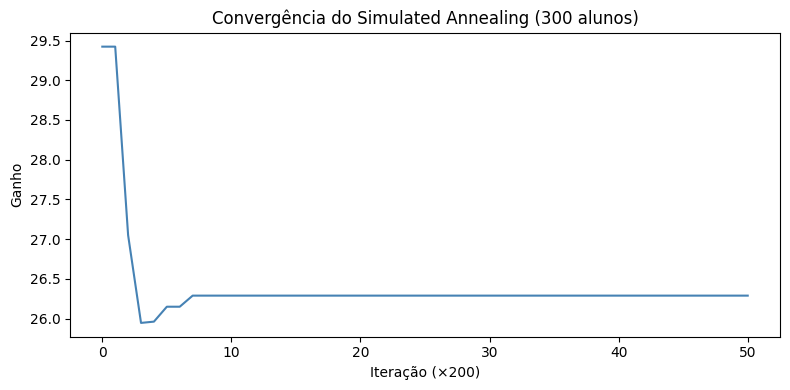

In [24]:
import matplotlib.pyplot as plt

# SA nos 50 alunos (comparação com exato)
t0 = time.time()
sol_sa_50, ganho_sa_50, hist_sa_50 = simulated_annealing(usuarios_exato, gain_ex, custo_ex)
t_sa_50 = time.time() - t0
print(f"[50 alunos] SA: ganho={ganho_sa_50:.4f}  |  Tempo: {t_sa_50:.2f}s")

# SA nos 300 alunos
t0 = time.time()
sol_sa_300, ganho_sa_300, hist_sa_300 = simulated_annealing(todos_usuarios, gain_300, custo_300)
t_sa_300 = time.time() - t0
print(f"[300 alunos] SA: ganho={ganho_sa_300:.4f}  |  Tempo: {t_sa_300:.2f}s")

# Curva de convergência
plt.figure(figsize=(8, 4))
plt.plot(hist_sa_300, color='steelblue')
plt.xlabel('Iteração (×200)')
plt.ylabel('Ganho')
plt.title('Convergência do Simulated Annealing (300 alunos)')
plt.tight_layout()
plt.savefig('data/convergencia_sa.png', dpi=120)
plt.show()

---
## Método 4: GRASP (Greedy Randomized Adaptive Search Procedure)

In [25]:
def construcao_grasp(usuarios, gain, custo, alpha=0.3, rng=None):
    """Fase de construção gulosa-aleatória com RCL."""
    if rng is None:
        rng = random.Random()
    
    solucao = {(u,t,r): 0 for u in usuarios for t in range(N_SEMANAS) for r in TIPOS}
    budget_usado = [0] * N_SEMANAS
    interv_aluno = {u: 0 for u in usuarios}
    interv_semana_aluno = {(u,t): 0 for u in usuarios for t in range(N_SEMANAS)}
    
    candidatos = set(
        (u,t,r)
        for u in usuarios for t in range(N_SEMANAS) for r in TIPOS
    )

    while candidatos:
        viaveis = [
            (u,t,r) for (u,t,r) in candidatos
            if (
                interv_semana_aluno.get((u,t),0) == 0
                and interv_aluno.get(u,0) < MAX_INTERV_ALUNO
                and budget_usado[t] + custo[r] <= BUDGET_POR_SEMANA
            )
        ]
        if not viaveis:
            break

        scores = [(gain[u][t][r] / custo[r], u, t, r) for u,t,r in viaveis]
        scores.sort(reverse=True)
        g_max = scores[0][0]
        g_min = scores[-1][0]
        limiar = g_min + alpha * (g_max - g_min)
        rcl = [(u,t,r) for sc,u,t,r in scores if sc >= limiar]

        u, t, r = rng.choice(rcl)
        solucao[(u,t,r)] = 1
        budget_usado[t] += custo[r]
        interv_aluno[u] += 1
        interv_semana_aluno[(u,t)] += 1

        candidatos = {(uu,tt,rr) for uu,tt,rr in candidatos
                      if not (uu==u and tt==t)}

    ganho = sum(gain[u][t][r] for (u,t,r),v in solucao.items() if v==1)
    return solucao, ganho


def busca_local(solucao, usuarios, gain, custo):
    """Melhoria por troca de tipo de intervenção dentro de cada aluno."""
    melhorou = True
    budget_usado = [0] * N_SEMANAS
    for (u,t,r),v in solucao.items():
        if v == 1:
            budget_usado[t] += custo[r]

    while melhorou:
        melhorou = False
        for u in usuarios:
            for t in range(N_SEMANAS):
                r_atual = next((r for r in TIPOS if solucao.get((u,t,r),0)==1), None)
                if r_atual is None:
                    continue
                for r_novo in TIPOS:
                    if r_novo == r_atual:
                        continue
                    diff_c = custo[r_novo] - custo[r_atual]
                    if budget_usado[t] + diff_c <= BUDGET_POR_SEMANA:
                        delta = gain[u][t][r_novo] - gain[u][t][r_atual]
                        if delta > 1e-9:
                            solucao[(u,t,r_atual)] = 0
                            solucao[(u,t,r_novo)] = 1
                            budget_usado[t] += diff_c
                            melhorou = True
                            r_atual = r_novo

    ganho = sum(gain[u][t][r] for (u,t,r),v in solucao.items() if v==1)
    return solucao, ganho


def grasp(usuarios, gain, custo, n_iter=20, alpha=0.3, seed=42):
    rng = random.Random(seed)
    best_gain = -np.inf
    best_sol = None
    historico = []

    for it in range(n_iter):
        sol, g = construcao_grasp(usuarios, gain, custo, alpha=alpha, rng=rng)
        sol, g = busca_local(sol, usuarios, gain, custo)
        historico.append(g)
        if g > best_gain:
            best_gain = g
            best_sol = dict(sol)

    return best_sol, best_gain, historico

print("GRASP definido.")

GRASP definido.


In [26]:
# GRASP nos 50 alunos
t0 = time.time()
sol_grasp_50, ganho_grasp_50, hist_grasp_50 = grasp(usuarios_exato, gain_ex, custo_ex, n_iter=20)
t_grasp_50 = time.time() - t0
print(f"[50 alunos] GRASP: ganho={ganho_grasp_50:.4f}  |  Tempo: {t_grasp_50:.2f}s")

# GRASP nos 300 alunos
t0 = time.time()
sol_grasp_300, ganho_grasp_300, hist_grasp_300 = grasp(todos_usuarios, gain_300, custo_300, n_iter=20)
t_grasp_300 = time.time() - t0
print(f"[300 alunos] GRASP: ganho={ganho_grasp_300:.4f}  |  Tempo: {t_grasp_300:.2f}s")

[50 alunos] GRASP: ganho=19.9603  |  Tempo: 2.90s
[300 alunos] GRASP: ganho=20.5131  |  Tempo: 27.01s


In [29]:
ganhos_grasp_50 = []
for run in range(n_runs):
    _, ganho, _ = grasp(usuarios_exato, gain_ex, custo_ex, n_iter=20, alpha=0.3, seed=200+run)
    ganhos_grasp_50.append(ganho)

ganhos_grasp_50 = np.array(ganhos_grasp_50)
media_grasp_50 = np.mean(ganhos_grasp_50)
desvio_grasp_50 = np.std(ganhos_grasp_50)
melhora_abs_grasp_50 = np.mean(ganhos_grasp_50 - ganho_guloso_50_ref)
melhora_perc_grasp_50 = melhora_abs_grasp_50 / ganho_guloso_50_ref * 100

print(f"GRASP (50 alunos, 30 execuções):")
print(f"  Ganho médio: {media_grasp_50:.4f} ± {desvio_grasp_50:.4f}")
print(f"  Melhora absoluta média: {melhora_abs_grasp_50:.4f}")
print(f"  Melhora percentual média: {melhora_perc_grasp_50:.2f}%")

GRASP (50 alunos, 30 execuções):
  Ganho médio: 20.4345 ± 0.3063
  Melhora absoluta média: 0.3850
  Melhora percentual média: 1.92%


In [30]:
ganho_guloso_300_ref = ganho_guloso_300

ganhos_sa_300 = []
for run in range(n_runs):
    _, ganho, _ = simulated_annealing(todos_usuarios, gain_300, custo_300,
                                      seed=100+run)
    ganhos_sa_300.append(ganho)

ganhos_sa_300 = np.array(ganhos_sa_300)
media_sa_300 = np.mean(ganhos_sa_300)
desvio_sa_300 = np.std(ganhos_sa_300)
melhora_abs_sa_300 = np.mean(ganhos_sa_300 - ganho_guloso_300_ref)
melhora_perc_sa_300 = melhora_abs_sa_300 / ganho_guloso_300_ref * 100

ganhos_grasp_300 = []
for run in range(n_runs):
    _, ganho, _ = grasp(todos_usuarios, gain_300, custo_300, n_iter=20, seed=200+run)
    ganhos_grasp_300.append(ganho)

ganhos_grasp_300 = np.array(ganhos_grasp_300)
media_grasp_300 = np.mean(ganhos_grasp_300)
desvio_grasp_300 = np.std(ganhos_grasp_300)
melhora_abs_grasp_300 = np.mean(ganhos_grasp_300 - ganho_guloso_300_ref)
melhora_perc_grasp_300 = melhora_abs_grasp_300 / ganho_guloso_300_ref * 100

In [31]:
tab_rob = pd.DataFrame({
    'Método': ['SA (50)', 'GRASP (50)'],
    'Ganho médio': [f"{media_sa_50:.4f} ± {desvio_sa_50:.4f}", 
                    f"{media_grasp_50:.4f} ± {desvio_grasp_50:.4f}"],
    'Melhora abs. média': [f"{melhora_abs_sa_50:.4f}", f"{melhora_abs_grasp_50:.4f}"],
    'Melhora % média': [f"{melhora_perc_sa_50:.2f}%", f"{melhora_perc_grasp_50:.2f}%"]
})
print(tab_rob.to_string(index=False))

    Método      Ganho médio Melhora abs. média Melhora % média
   SA (50) 20.9079 ± 0.4130             0.8585           4.28%
GRASP (50) 20.4345 ± 0.3063             0.3850           1.92%


In [28]:
n_runs = 30
ganho_guloso_50_ref = ganho_guloso_50  # já calculado

ganhos_sa_50 = []
for run in range(n_runs):
    _, ganho, _ = simulated_annealing(usuarios_exato, gain_ex, custo_ex, 
                                      T0=1.0, alpha=0.995, T_min=1e-4, 
                                      max_iter=10000, seed=100+run)
    ganhos_sa_50.append(ganho)

ganhos_sa_50 = np.array(ganhos_sa_50)
media_sa_50 = np.mean(ganhos_sa_50)
desvio_sa_50 = np.std(ganhos_sa_50)
melhora_abs_sa_50 = np.mean(ganhos_sa_50 - ganho_guloso_50_ref)
melhora_perc_sa_50 = melhora_abs_sa_50 / ganho_guloso_50_ref * 100

print(f"SA (50 alunos, 30 execuções):")
print(f"  Ganho médio: {media_sa_50:.4f} ± {desvio_sa_50:.4f}")
print(f"  Melhora absoluta média: {melhora_abs_sa_50:.4f}")
print(f"  Melhora percentual média: {melhora_perc_sa_50:.2f}%")

SA (50 alunos, 30 execuções):
  Ganho médio: 20.9079 ± 0.4130
  Melhora absoluta média: 0.8585
  Melhora percentual média: 4.28%


In [15]:
# ============================================================
# Sumário comparativo (instância 50 alunos — comparável ao exato)
# ============================================================
gap_guloso = (ganho_exato - ganho_guloso_50) / ganho_exato * 100 if ganho_exato > 0 else 0
gap_sa     = (ganho_exato - ganho_sa_50)     / ganho_exato * 100 if ganho_exato > 0 else 0
gap_grasp  = (ganho_exato - ganho_grasp_50)  / ganho_exato * 100 if ganho_exato > 0 else 0

print("\n" + "="*65)
print(f"{'Método':<25} {'Ganho':>10} {'Gap (%)':>10} {'Tempo (s)':>12}")
print("-"*65)
print(f"{'Exato (PuLP/CBC)':<25} {ganho_exato:>10.4f} {'—':>10} {t_exato:>12.2f}")
print(f"{'Guloso':<25} {ganho_guloso_50:>10.4f} {gap_guloso:>9.2f}% {t_guloso_50:>12.4f}")
print(f"{'Simulated Annealing':<25} {ganho_sa_50:>10.4f} {gap_sa:>9.2f}% {t_sa_50:>12.2f}")
print(f"{'GRASP':<25} {ganho_grasp_50:>10.4f} {gap_grasp:>9.2f}% {t_grasp_50:>12.2f}")
print("="*65)

# Salvar resultados
resultados = {
    'instancia_50': {
        'exato':  {'ganho': ganho_exato,    'tempo': t_exato,     'gap': 0},
        'guloso': {'ganho': ganho_guloso_50,'tempo': t_guloso_50, 'gap': gap_guloso},
        'sa':     {'ganho': ganho_sa_50,    'tempo': t_sa_50,     'gap': gap_sa},
        'grasp':  {'ganho': ganho_grasp_50, 'tempo': t_grasp_50,  'gap': gap_grasp},
    },
    'instancia_300': {
        'guloso': {'ganho': ganho_guloso_300, 'tempo': t_guloso_300},
        'sa':     {'ganho': ganho_sa_300,     'tempo': t_sa_300},
        'grasp':  {'ganho': ganho_grasp_300,  'tempo': t_grasp_300},
    },
    'convergencia_sa':    hist_sa_300,
    'convergencia_grasp': hist_grasp_300,
}

with open('data/resultados.pkl', 'wb') as f:
    pickle.dump(resultados, f)

print("\nResultados salvos em data/resultados.pkl")


Método                         Ganho    Gap (%)    Tempo (s)
-----------------------------------------------------------------
Exato (PuLP/CBC)             25.2660          —         0.70
Guloso                       20.0494     20.65%       0.0029
Simulated Annealing          21.1091     16.45%         0.69
GRASP                        19.9603     21.00%         2.94

Resultados salvos em data/resultados.pkl
